
===== Houston =====
embed exists: True /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_alphaearth_2024_tract_mean_mosaic_clean.csv
heat exists : True /Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_master_with_lst_hi_fixed.gpkg
pc exists   : True /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_alphaearth_pc7_scores_corrected.csv
merged rows: 654
target non-null: 549
baseline cols: ['median_household_income_clean', 'total_population_clean', 'poverty_rate', 'ALAND', 'AWATER']
pc cols: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7']
stable raw dims: ['A02', 'A04', 'A07', 'A16', 'A17', 'A22', 'A25', 'A28', 'A31', 'A32', 'A34', 'A42', 'A51', 'A56', 'A59']

===== Phoenix =====
embed exists: True /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_alphaearth_2024_tract_mean_mosaic_clean.csv
heat exists : True /Users/yufeizhou/Desktop/heat-exposure-compare/data_processed

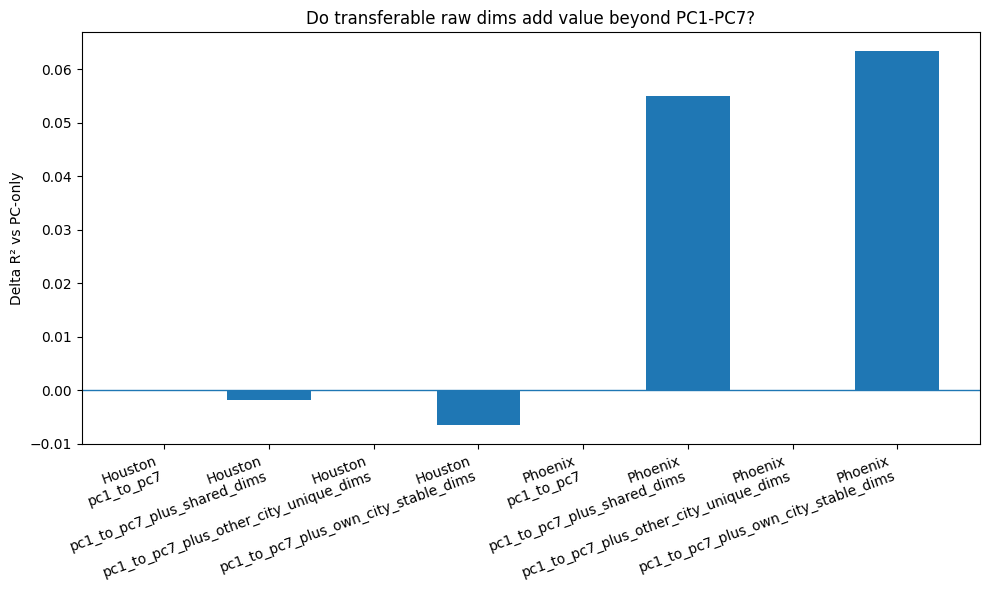


Saved files:
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_transfer_plus_pc_summary.csv
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_transfer_plus_pc_meeting_table.csv
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_transfer_plus_pc_best_by_city.csv
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_transfer_plus_pc_delta_vs_pc_only.png

===== Final summary =====


,city,model,n_rows,n_features,cv_r2_mean,cv_r2_std,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,note,features,pc_only_r2,delta_vs_pc_only,model_order
0,Houston,baseline_plus_pc1_to_pc7,541,12,0.784899,0.065437,1.283161,0.197907,0.921733,0.079648,,"median_household_income_clean, total_populatio...",0.784899,0.000000e+00,0
1,Houston,baseline_plus_pc1_to_pc7_plus_shared_dims,541,15,0.783135,0.062100,1.290507,0.194471,0.927538,0.083848,,"median_household_income_clean, total_populatio...",0.784899,-1.764056e-03,1
2,Houston,baseline_plus_pc1_to_pc7_plus_other_city_uniqu...,541,12,0.784899,0.065437,1.283161,0.197907,0.921733,0.079648,,"median_household_income_clean, total_populatio...",0.784899,0.000000e+00,2
3,Houston,baseline_plus_pc1_to_pc7_plus_own_city_stable_...,541,27,0.778313,0.047896,1.305695,0.156495,0.921155,0.076563,,"median_household_income_clean, total_populatio...",0.784899,-6.586302e-03,3
4,Phoenix,baseline_plus_pc1_to_pc7,329,12,0.667663,0.057883,0.954644,0.060523,0.747565,0.058081,,"median_household_income_clean, total_populatio...",0.667663,0.000000e+00,0
5,Phoenix,baseline_plus_pc1_to_pc7_plus_shared_dims,329,15,0.722658,0.059629,0.870694,0.094199,0.676365,0.084649,,"median_household_income_clean, total_populatio...",0.667663,5.499450e-02,1
6,Phoenix,baseline_plus_pc1_to_pc7_plus_other_city_uniqu...,329,12,0.667663,0.057883,0.954644,0.060523,0.747565,0.058081,,"median_household_income_clean, total_populatio...",0.667663,1.110223e-16,2
7,Phoenix,baseline_plus_pc1_to_pc7_plus_own_city_stable_...,329,28,0.731089,0.059838,0.857298,0.100436,0.669401,0.092544,,"median_household_income_clean, total_populatio...",0.667663,6.342556e-02,3



===== Best model by city =====


,city,model,n_rows,n_features,cv_r2_mean,cv_r2_std,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,note,features,pc_only_r2,delta_vs_pc_only,model_order
0,Houston,baseline_plus_pc1_to_pc7,541,12,0.784899,0.065437,1.283161,0.197907,0.921733,0.079648,,"median_household_income_clean, total_populatio...",0.784899,0.000000,0
1,Phoenix,baseline_plus_pc1_to_pc7_plus_own_city_stable_...,329,28,0.731089,0.059838,0.857298,0.100436,0.669401,0.092544,,"median_household_income_clean, total_populatio...",0.667663,0.063426,3


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_validate

# =========================================================
# 0. paths
# =========================================================
ROOT = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")
OUT = ROOT / "outputs/pilot/alphaearth"
OUT.mkdir(parents=True, exist_ok=True)

city_cfg = {
    "Houston": {
        "embed_file": OUT / "houston_alphaearth_2024_tract_mean_mosaic_clean.csv",
        "heat_file": ROOT / "data_processed/houston/houston_master_with_lst_hi_fixed.gpkg",
        "pc_file": OUT / "houston_alphaearth_pc7_scores_corrected.csv",
    },
    "Phoenix": {
        "embed_file": OUT / "phoenix_alphaearth_2024_tract_mean_mosaic_clean.csv",
        "heat_file": ROOT / "data_processed/phoenix/phoenix_master_with_lst_hi_fixed.gpkg",
        "pc_file": OUT / "phoenix_alphaearth_pc7_scores_corrected.csv",
    },
}

selected_dims_file = OUT / "city_rawdim_selected_dims.csv"

# =========================================================
# 1. helpers
# =========================================================
def standardize_geoid(s):
    s = s.astype(str).str.strip()
    s = s.str.replace(r"\.0$", "", regex=True)
    s = s.str.replace(r"\s+", "", regex=True)
    return s

def pick_first_existing(df, candidates, required=True):
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand in df.columns:
            return cand
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    if required:
        raise KeyError(f"Cannot find any of {candidates} in columns: {list(df.columns)}")
    return None

def read_heat_table(path):
    path = Path(path)
    if path.suffix.lower() == ".gpkg":
        df = gpd.read_file(path)
        if "geometry" in df.columns:
            df = df.drop(columns="geometry")
        return df.copy()
    elif path.suffix.lower() == ".csv":
        return pd.read_csv(path).copy()
    else:
        raise ValueError(f"Unsupported file type: {path}")

def coerce_numeric_inplace(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

def dedupe_keep_order(seq):
    out = []
    seen = set()
    for x in seq:
        if x not in seen:
            out.append(x)
            seen.add(x)
    return out

def build_city_df(city_name, cfg, selected_dims_df):
    print(f"\n===== {city_name} =====")
    embed_file = Path(cfg["embed_file"])
    heat_file = Path(cfg["heat_file"])
    pc_file = Path(cfg["pc_file"])

    print("embed exists:", embed_file.exists(), embed_file)
    print("heat exists :", heat_file.exists(), heat_file)
    print("pc exists   :", pc_file.exists(), pc_file)

    if not embed_file.exists():
        raise FileNotFoundError(f"{city_name} embed file not found: {embed_file}")
    if not heat_file.exists():
        raise FileNotFoundError(f"{city_name} heat file not found: {heat_file}")
    if not pc_file.exists():
        raise FileNotFoundError(f"{city_name} pc file not found: {pc_file}")

    embed_df = pd.read_csv(embed_file, dtype={"GEOID": str}).copy()
    heat_df = read_heat_table(heat_file).copy()
    pc_df = pd.read_csv(pc_file, dtype={"GEOID": str}).copy()

    geoid_embed = pick_first_existing(embed_df, ["GEOID", "geoid"])
    geoid_heat = pick_first_existing(heat_df, ["GEOID", "geoid"])
    geoid_pc = pick_first_existing(pc_df, ["GEOID", "geoid"])

    embed_df["GEOID"] = standardize_geoid(embed_df[geoid_embed])
    heat_df["GEOID"] = standardize_geoid(heat_df[geoid_heat])
    pc_df["GEOID"] = standardize_geoid(pc_df[geoid_pc])

    width = int(
        max(
            embed_df["GEOID"].str.len().max(),
            heat_df["GEOID"].str.len().max(),
            pc_df["GEOID"].str.len().max(),
        )
    )
    embed_df["GEOID"] = embed_df["GEOID"].str.zfill(width)
    heat_df["GEOID"] = heat_df["GEOID"].str.zfill(width)
    pc_df["GEOID"] = pc_df["GEOID"].str.zfill(width)

    lst_col = pick_first_existing(heat_df, ["lst_c", "lst_summer_mean_c", "lst"])
    hi_col = pick_first_existing(heat_df, ["hi_c", "hi_summer_mean_c", "hi"], required=False)

    income_col = pick_first_existing(
        heat_df,
        ["median_household_income_clean", "median_household_income", "income"]
    )
    poverty_col = pick_first_existing(
        heat_df,
        ["poverty_rate", "poverty", "poverty_pct"],
        required=False
    )
    pop_col = pick_first_existing(
        heat_df,
        ["total_population_clean", "total_population", "population", "pop"]
    )
    aland_col = pick_first_existing(heat_df, ["ALAND", "aland"], required=False)
    awater_col = pick_first_existing(heat_df, ["AWATER", "awater"], required=False)

    if "hi_minus_lst" not in heat_df.columns:
        if hi_col is not None and lst_col is not None:
            heat_df["hi_minus_lst"] = (
                pd.to_numeric(heat_df[hi_col], errors="coerce")
                - pd.to_numeric(heat_df[lst_col], errors="coerce")
            )

    keep_heat = ["GEOID", lst_col, income_col, pop_col]
    if hi_col is not None:
        keep_heat.append(hi_col)
    if poverty_col is not None:
        keep_heat.append(poverty_col)
    if aland_col is not None:
        keep_heat.append(aland_col)
    if awater_col is not None:
        keep_heat.append(awater_col)
    if "hi_minus_lst" in heat_df.columns:
        keep_heat.append("hi_minus_lst")

    heat_df = heat_df[sorted(set(keep_heat))].copy()

    numeric_candidates = [c for c in heat_df.columns if c != "GEOID"]
    coerce_numeric_inplace(heat_df, numeric_candidates)

    city_dims = (
        selected_dims_df.loc[selected_dims_df["city"] == city_name, "selected_raw_dim"]
        .dropna()
        .astype(str)
        .tolist()
    )
    city_dims = [d for d in city_dims if d in embed_df.columns]

    df_city = embed_df[["GEOID"] + city_dims].merge(heat_df, on="GEOID", how="inner")
    df_city = df_city.merge(pc_df, on="GEOID", how="inner")

    pc_cols = [c for c in [f"PC{i}" for i in range(1, 8)] if c in df_city.columns]

    baseline_cols = [income_col, pop_col]
    if poverty_col is not None:
        baseline_cols.append(poverty_col)
    if aland_col is not None:
        baseline_cols.append(aland_col)
    if awater_col is not None:
        baseline_cols.append(awater_col)

    baseline_cols = [c for c in baseline_cols if c in df_city.columns]

    target_col = "hi_minus_lst"
    if target_col not in df_city.columns or df_city[target_col].isna().all():
        if hi_col is not None and lst_col is not None and hi_col in df_city.columns and lst_col in df_city.columns:
            df_city[target_col] = (
                pd.to_numeric(df_city[hi_col], errors="coerce")
                - pd.to_numeric(df_city[lst_col], errors="coerce")
            )

    model_numeric_cols = city_dims + baseline_cols + pc_cols + [target_col]
    model_numeric_cols = [c for c in model_numeric_cols if c in df_city.columns]
    coerce_numeric_inplace(df_city, model_numeric_cols)

    print("merged rows:", len(df_city))
    print("target non-null:", df_city[target_col].notna().sum())
    print("baseline cols:", baseline_cols)
    print("pc cols:", pc_cols)
    print("stable raw dims:", city_dims)

    return {
        "city": city_name,
        "df": df_city,
        "baseline_cols": baseline_cols,
        "pc_cols": pc_cols,
        "raw_dims": city_dims,
        "target_col": target_col,
    }

def eval_model(df, feature_cols, target_col, model_name, city_name):
    feature_cols = dedupe_keep_order([c for c in feature_cols if c in df.columns])

    use_cols = feature_cols + [target_col]
    sub = df[use_cols].dropna().copy()

    print(f"{city_name} / {model_name} usable rows after dropna:", len(sub))

    if len(sub) < 50:
        return {
            "city": city_name,
            "model": model_name,
            "n_rows": len(sub),
            "n_features": len(feature_cols),
            "cv_r2_mean": np.nan,
            "cv_r2_std": np.nan,
            "cv_rmse_mean": np.nan,
            "cv_rmse_std": np.nan,
            "cv_mae_mean": np.nan,
            "cv_mae_std": np.nan,
            "note": f"too_few_rows_after_dropna_{len(sub)}",
            "features": ", ".join(feature_cols),
        }

    X = sub[feature_cols]
    y = sub[target_col]

    rf = RandomForestRegressor(
        n_estimators=400,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scoring = {
        "r2": "r2",
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error"
    }

    res = cross_validate(
        rf, X, y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    return {
        "city": city_name,
        "model": model_name,
        "n_rows": len(sub),
        "n_features": X.shape[1],
        "cv_r2_mean": np.mean(res["test_r2"]),
        "cv_r2_std": np.std(res["test_r2"]),
        "cv_rmse_mean": -np.mean(res["test_rmse"]),
        "cv_rmse_std": np.std(-res["test_rmse"]),
        "cv_mae_mean": -np.mean(res["test_mae"]),
        "cv_mae_std": np.std(-res["test_mae"]),
        "note": "",
        "features": ", ".join(feature_cols),
    }

# =========================================================
# 2. build city data
# =========================================================
selected_dims_df = pd.read_csv(selected_dims_file).copy()

city_data = {}
for city, cfg in city_cfg.items():
    city_data[city] = build_city_df(city, cfg, selected_dims_df)

shared_dims = sorted(
    list(set(city_data["Houston"]["raw_dims"]).intersection(set(city_data["Phoenix"]["raw_dims"])))
)

print("\nShared dims:", shared_dims)

# =========================================================
# 3. evaluate models
# =========================================================
rows = []

for city in ["Houston", "Phoenix"]:
    other_city = "Phoenix" if city == "Houston" else "Houston"

    df_city = city_data[city]["df"].copy()
    baseline_cols = city_data[city]["baseline_cols"]
    pc_cols = city_data[city]["pc_cols"]
    own_dims = city_data[city]["raw_dims"]
    other_dims = city_data[other_city]["raw_dims"]
    target_col = city_data[city]["target_col"]

    other_city_unique_dims = sorted(list(set(other_dims) - set(own_dims)))

    model_specs = [
        ("baseline_plus_pc1_to_pc7", baseline_cols + pc_cols),
        ("baseline_plus_pc1_to_pc7_plus_shared_dims", baseline_cols + pc_cols + shared_dims),
        ("baseline_plus_pc1_to_pc7_plus_other_city_unique_dims", baseline_cols + pc_cols + other_city_unique_dims),
        ("baseline_plus_pc1_to_pc7_plus_own_city_stable_dims", baseline_cols + pc_cols + own_dims),
    ]

    print(f"\n===== evaluating {city} =====")
    print("target col:", target_col)

    for model_name, feats in model_specs:
        out = eval_model(df_city, feats, target_col, model_name, city)
        rows.append(out)
        print(model_name, "-> r2 =", out["cv_r2_mean"], "| n =", out["n_rows"], "| note =", out["note"])

summary_df = pd.DataFrame(rows)

# =========================================================
# 4. delta vs pc-only
# =========================================================
pc_only_df = (
    summary_df.loc[summary_df["model"] == "baseline_plus_pc1_to_pc7", ["city", "cv_r2_mean"]]
    .rename(columns={"cv_r2_mean": "pc_only_r2"})
)

summary_df = summary_df.merge(pc_only_df, on="city", how="left")
summary_df["delta_vs_pc_only"] = summary_df["cv_r2_mean"] - summary_df["pc_only_r2"]

order = [
    "baseline_plus_pc1_to_pc7",
    "baseline_plus_pc1_to_pc7_plus_shared_dims",
    "baseline_plus_pc1_to_pc7_plus_other_city_unique_dims",
    "baseline_plus_pc1_to_pc7_plus_own_city_stable_dims",
]
summary_df["model_order"] = summary_df["model"].map({m: i for i, m in enumerate(order)})
summary_df = summary_df.sort_values(["city", "model_order"]).reset_index(drop=True)

# =========================================================
# 5. save outputs
# =========================================================
summary_csv = OUT / "city_transfer_plus_pc_summary.csv"
meeting_csv = OUT / "city_transfer_plus_pc_meeting_table.csv"
best_csv = OUT / "city_transfer_plus_pc_best_by_city.csv"
plot_png = OUT / "city_transfer_plus_pc_delta_vs_pc_only.png"

summary_df.to_csv(summary_csv, index=False)

meeting_df = summary_df[
    [
        "city", "model", "n_rows", "n_features",
        "cv_r2_mean", "cv_r2_std",
        "cv_rmse_mean", "cv_mae_mean",
        "pc_only_r2", "delta_vs_pc_only", "note"
    ]
].copy()
meeting_df.to_csv(meeting_csv, index=False)

best_df = (
    summary_df.sort_values(["city", "cv_r2_mean"], ascending=[True, False])
    .groupby("city")
    .head(1)
    .reset_index(drop=True)
)
best_df.to_csv(best_csv, index=False)

# =========================================================
# 6. plot
# =========================================================
plot_df = summary_df.copy()
plot_df["label"] = plot_df["city"] + "\n" + plot_df["model"].str.replace("baseline_plus_", "", regex=False)

plt.figure(figsize=(10, 6))
plt.bar(plot_df["label"], plot_df["delta_vs_pc_only"])
plt.axhline(0, linewidth=1)
plt.ylabel("Delta R² vs PC-only")
plt.title("Do transferable raw dims add value beyond PC1-PC7?")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(plot_png, dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved files:")
print(summary_csv)
print(meeting_csv)
print(best_csv)
print(plot_png)

print("\n===== Final summary =====")
display(summary_df)

print("\n===== Best model by city =====")
display(best_df)

In [3]:
# ===== FIX for notebook 13: robust heat-layer reader =====

from pathlib import Path
import re
import numpy as np
import pandas as pd
import geopandas as gpd

try:
    import pyogrio
except ImportError:
    pyogrio = None

try:
    import fiona
except ImportError:
    fiona = None


# =========================
# paths
# =========================
ROOT = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")
OUT = ROOT / "outputs" / "pilot" / "alphaearth"
OUT.mkdir(parents=True, exist_ok=True)

city_cfg = {
    "Houston": {
        "embed_file": ROOT / "outputs/pilot/alphaearth/houston_alphaearth_2024_tract_mean_mosaic_clean.csv",
        "heat_file": ROOT / "data_processed/houston/houston_master_with_lst_hi_fixed.gpkg",
        "pc_file": ROOT / "outputs/pilot/alphaearth/houston_alphaearth_pc7_scores_corrected.csv",
    },
    "Phoenix": {
        "embed_file": ROOT / "outputs/pilot/alphaearth/phoenix_alphaearth_2024_tract_mean_mosaic_clean.csv",
        "heat_file": ROOT / "data_processed/phoenix/phoenix_master_with_lst_hi_fixed.gpkg",
        "pc_file": ROOT / "outputs/pilot/alphaearth/phoenix_alphaearth_pc7_scores_corrected.csv",
    },
}


# =========================
# helpers
# =========================
def clean_geoid_series(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip()
    s = s.str.replace(r"\.0$", "", regex=True)
    s = s.str.replace("nan", "", regex=False)
    s = s.str.zfill(11)
    return s


def pick_first_existing(cols, candidates, required=True):
    lower_map = {str(c).lower(): c for c in cols}
    for cand in candidates:
        if cand in cols:
            return cand
        if str(cand).lower() in lower_map:
            return lower_map[str(cand).lower()]
    if required:
        raise KeyError(f"Cannot find any of {candidates} in columns: {list(cols)}")
    return None


def sort_pc_cols(cols):
    pcs = [c for c in cols if re.fullmatch(r"PC\d+", str(c))]
    return sorted(pcs, key=lambda x: int(re.findall(r"\d+", x)[0]))


def sort_raw_cols(cols):
    raws = [c for c in cols if re.fullmatch(r"A\d{2}", str(c))]
    return sorted(raws, key=lambda x: int(str(x)[1:]))


def list_gpkg_layers(path: Path):
    path = Path(path)
    layers = []

    if pyogrio is not None:
        try:
            info = pyogrio.list_layers(path)
            layers = [str(row[0]) for row in info]
        except Exception:
            pass

    if not layers and fiona is not None:
        try:
            layers = list(fiona.listlayers(path))
        except Exception:
            pass

    return layers


def score_heat_columns(cols):
    lower = {str(c).lower() for c in cols}
    score = 0

    # strongest signal: direct target exists
    if "hi_minus_lst" in lower or "hi_minus_lst_clean" in lower:
        score += 100

    # second best: reconstructable target
    if "hi_c" in lower:
        score += 30
    if "lst_c" in lower:
        score += 30

    # observable variables
    if "median_household_income_clean" in lower or "median_household_income" in lower:
        score += 10
    if "total_population_clean" in lower or "total_population" in lower or "population" in lower:
        score += 10
    if "poverty_rate" in lower or "poverty_rate_clean" in lower:
        score += 10
    if "aland" in lower:
        score += 5
    if "awater" in lower:
        score += 5

    # geoid
    if "geoid" in lower:
        score += 5

    return score


def read_best_heat_table(path: Path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Heat file not found: {path}")

    candidates = []

    # try default read
    try:
        df0 = gpd.read_file(path)
        candidates.append(("__default__", score_heat_columns(df0.columns), df0))
    except Exception as e:
        print(f"default read failed for {path.name}: {e}")

    # if gpkg, also scan layers
    if path.suffix.lower() == ".gpkg":
        layers = list_gpkg_layers(path)
        for layer in layers:
            try:
                df_layer = gpd.read_file(path, layer=layer)
                candidates.append((layer, score_heat_columns(df_layer.columns), df_layer))
            except Exception as e:
                print(f"layer read failed [{layer}] for {path.name}: {e}")

    if len(candidates) == 0:
        raise ValueError(f"Could not read any table/layer from {path}")

    candidates_sorted = sorted(candidates, key=lambda x: x[1], reverse=True)
    best_layer, best_score, best_df = candidates_sorted[0]

    print(f"Selected heat layer: {best_layer} | score={best_score}")
    print("Heat columns preview:", list(best_df.columns)[:20])

    if best_score == 0:
        raise KeyError(
            f"No suitable heat layer found in {path}. "
            f"Top candidate columns: {list(best_df.columns)}"
        )

    return best_df.copy(), best_layer, best_score


def build_city_df(city_name, cfg):
    print(f"\n===== {city_name} =====")

    embed_file = Path(cfg["embed_file"])
    heat_file = Path(cfg["heat_file"])
    pc_file = Path(cfg["pc_file"])

    print("embed exists:", embed_file.exists(), embed_file)
    print("heat exists :", heat_file.exists(), heat_file)
    print("pc exists   :", pc_file.exists(), pc_file)

    if not embed_file.exists():
        raise FileNotFoundError(f"{city_name} embed file missing: {embed_file}")
    if not heat_file.exists():
        raise FileNotFoundError(f"{city_name} heat file missing: {heat_file}")
    if not pc_file.exists():
        raise FileNotFoundError(f"{city_name} pc file missing: {pc_file}")

    # ---------- embed ----------
    embed = pd.read_csv(embed_file).copy()
    embed_geoid_col = pick_first_existing(embed.columns, ["GEOID", "geoid"])
    embed["GEOID"] = clean_geoid_series(embed[embed_geoid_col])

    raw_cols = sort_raw_cols(embed.columns)
    if len(raw_cols) == 0:
        raise ValueError(f"{city_name}: no raw A## columns found in embed file")

    for c in raw_cols:
        embed[c] = pd.to_numeric(embed[c], errors="coerce")

    # ---------- heat ----------
    heat, selected_layer, selected_score = read_best_heat_table(heat_file)

    heat_geoid_col = pick_first_existing(heat.columns, ["GEOID", "geoid"])
    heat["GEOID"] = clean_geoid_series(heat[heat_geoid_col])

    # target: direct or reconstructed
    target_col = pick_first_existing(
        heat.columns,
        ["hi_minus_lst", "HI_MINUS_LST", "hi_minus_lst_clean"],
        required=False
    )

    hi_col = pick_first_existing(
        heat.columns,
        ["hi_c", "HI_C"],
        required=False
    )

    lst_col = pick_first_existing(
        heat.columns,
        ["lst_c", "LST_C"],
        required=False
    )

    if target_col is None:
        if hi_col is not None and lst_col is not None:
            heat["hi_minus_lst"] = (
                pd.to_numeric(heat[hi_col], errors="coerce")
                - pd.to_numeric(heat[lst_col], errors="coerce")
            )
            target_col = "hi_minus_lst"
            print(f"{city_name}: hi_minus_lst reconstructed from {hi_col} - {lst_col}")
        else:
            raise KeyError(
                f"{city_name}: cannot find hi_minus_lst, and also cannot reconstruct it. "
                f"Columns preview: {list(heat.columns)}"
            )
    else:
        if target_col != "hi_minus_lst":
            heat["hi_minus_lst"] = pd.to_numeric(heat[target_col], errors="coerce")
            target_col = "hi_minus_lst"

    income_col = pick_first_existing(
        heat.columns,
        ["median_household_income_clean", "median_household_income"]
    )
    pop_col = pick_first_existing(
        heat.columns,
        ["total_population_clean", "total_population", "population"]
    )
    poverty_col = pick_first_existing(
        heat.columns,
        ["poverty_rate", "poverty_rate_clean"]
    )
    aland_col = pick_first_existing(heat.columns, ["ALAND"])
    awater_col = pick_first_existing(heat.columns, ["AWATER"])

    heat_keep = ["GEOID", target_col, income_col, pop_col, poverty_col, aland_col, awater_col]
    heat_sub = heat[heat_keep].copy()

    heat_sub = heat_sub.rename(columns={
        target_col: "hi_minus_lst",
        income_col: "median_household_income_clean",
        pop_col: "total_population_clean",
        poverty_col: "poverty_rate",
        aland_col: "ALAND",
        awater_col: "AWATER",
    })

    for c in [
        "hi_minus_lst",
        "median_household_income_clean",
        "total_population_clean",
        "poverty_rate",
        "ALAND",
        "AWATER",
    ]:
        heat_sub[c] = pd.to_numeric(heat_sub[c], errors="coerce")

    # ---------- pc ----------
    pc = pd.read_csv(pc_file).copy()
    pc_geoid_col = pick_first_existing(pc.columns, ["GEOID", "geoid"])
    pc["GEOID"] = clean_geoid_series(pc[pc_geoid_col])

    pc_cols = sort_pc_cols(pc.columns)
    if len(pc_cols) == 0:
        raise ValueError(f"{city_name}: no PC columns found in pc file")

    for c in pc_cols:
        pc[c] = pd.to_numeric(pc[c], errors="coerce")

    # ---------- merge ----------
    df = (
        embed[["GEOID"] + raw_cols]
        .merge(heat_sub, on="GEOID", how="inner")
        .merge(pc[["GEOID"] + pc_cols], on="GEOID", how="inner")
    )

    print(f"{city_name}: selected heat layer = {selected_layer} | score = {selected_score}")
    print("embed rows:", len(embed))
    print("heat rows :", len(heat_sub))
    print("pc rows   :", len(pc))
    print("merged rows:", len(df))
    print("target non-null:", df["hi_minus_lst"].notna().sum())
    print("raw dims kept:", len(raw_cols))
    print("pc cols:", pc_cols)

    miss_cols = [
        "hi_minus_lst",
        "median_household_income_clean",
        "total_population_clean",
        "poverty_rate",
        "ALAND",
        "AWATER",
    ] + pc_cols

    miss = df[miss_cols].isna().sum().sort_values(ascending=False)
    print("\nMissingness preview:")
    display(miss.reset_index().rename(columns={"index": "column", 0: "missing_n"}).head(12))

    return df, raw_cols, pc_cols


# =========================
# rebuild city_data
# =========================
city_data = {}
for city, cfg in city_cfg.items():
    city_data[city] = build_city_df(city, cfg)

print("\ncity_data rebuilt successfully.")
for city in city_data:
    df_city, raw_city, pc_city = city_data[city]
    print(f"{city}: merged={len(df_city)}, raw_dims={len(raw_city)}, pc_cols={len(pc_city)}")


===== Houston =====
embed exists: True /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_alphaearth_2024_tract_mean_mosaic_clean.csv
heat exists : True /Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_master_with_lst_hi_fixed.gpkg
pc exists   : True /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_alphaearth_pc7_scores_corrected.csv
Selected heat layer: __default__ | score=105
Heat columns preview: ['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'NAME', 'NAMELSAD', 'ALAND', 'AWATER', 'area_km2', 'city', 'total_population', 'median_household_income', 'total_population_clean', 'median_household_income_clean', 'poverty_universe', 'below_poverty_count', 'poverty_universe_clean', 'below_poverty_count_clean', 'poverty_rate', 'low_income_flag']
Houston: hi_minus_lst reconstructed from hi_c - lst_c
Houston: selected heat layer = __default__ | score = 105
embed rows: 654
heat rows : 654
pc rows   : 654
merged

,column,missing_n
0,hi_minus_lst,105
1,median_household_income_clean,9
2,poverty_rate,3
3,total_population_clean,0
4,ALAND,0
5,AWATER,0
6,PC1,0
7,PC2,0
8,PC3,0
9,PC4,0



===== Phoenix =====
embed exists: True /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_alphaearth_2024_tract_mean_mosaic_clean.csv
heat exists : True /Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_master_with_lst_hi_fixed.gpkg
pc exists   : True /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_alphaearth_pc7_scores_corrected.csv
Selected heat layer: __default__ | score=105
Heat columns preview: ['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'NAME', 'NAMELSAD', 'ALAND', 'AWATER', 'area_km2', 'city', 'total_population', 'median_household_income', 'total_population_clean', 'median_household_income_clean', 'poverty_universe', 'below_poverty_count', 'poverty_universe_clean', 'below_poverty_count_clean', 'poverty_rate', 'low_income_flag']
Phoenix: hi_minus_lst reconstructed from hi_c - lst_c
Phoenix: selected heat layer = __default__ | score = 105
embed rows: 373
heat rows : 373
pc rows   : 373
merged

,column,missing_n
0,hi_minus_lst,41
1,median_household_income_clean,5
2,poverty_rate,3
3,total_population_clean,0
4,ALAND,0
5,AWATER,0
6,PC1,0
7,PC2,0
8,PC3,0
9,PC4,0



city_data rebuilt successfully.
Houston: merged=654, raw_dims=64, pc_cols=7
Phoenix: merged=373, raw_dims=64, pc_cols=7
